多层感知机

激活函数

In [5]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [6]:
print(torch.cuda.is_available())

True


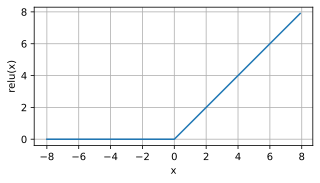

In [7]:
#ReLU函数 ReLU(x) = max(0, x)
x=torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y=torch.relu(x)
d2l.plot(x.detach(),y.detach(),'x','relu(x)',figsize=(5,2.5))

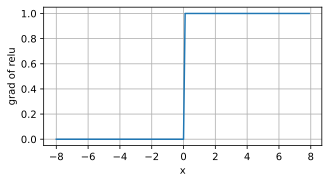

In [8]:
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(),x.grad,'x','grad of relu',figsize=(5,2.5))

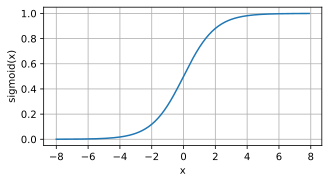

In [9]:
##Sigmoid函数 sigmoid(x) = 1/(1+exp(-x))
y=torch.sigmoid(x)
d2l.plot(x.detach(),y.detach(),'x','sigmoid(x)',figsize=(5,2.5))

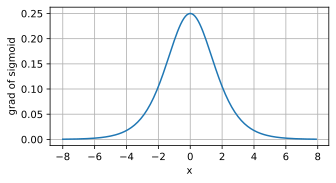

In [10]:
x.grad.zero_()
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(),x.grad,'x','grad of sigmoid',figsize=(5,2.5))

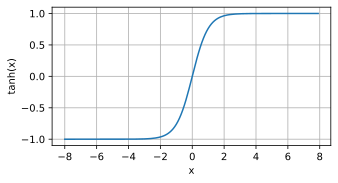

In [11]:
##Tanh函数 tanh(x) = (exp(x)-exp(-x))/(exp(x)+exp(-x))
y=torch.tanh(x)
d2l.plot(x.detach(),y.detach(),'x','tanh(x)',figsize=(5,2.5))

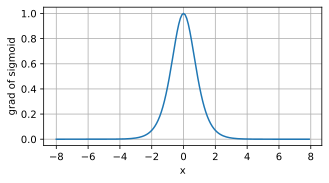

In [12]:
x.grad.zero_()
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(),x.grad,'x','grad of sigmoid',figsize=(5,2.5))

多层感知机从0开始

In [13]:
import torch
from torch import nn
from d2l import torch as d2l
batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)
#初始化模型参数
num_inputs,num_outputs,num_hiddens=784,10,256
W1=nn.Parameter(torch.randn(
  num_inputs, num_hiddens, requires_grad=True)*0.01)
b1=nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2=nn.Parameter(torch.randn(
  num_hiddens, num_outputs, requires_grad=True)*0.01)
b2=nn.Parameter(torch.zeros(num_outputs, requires_grad=True))
params=[W1,b1,W2,b2]

In [14]:
##激活函数
def relu(X):
    a=torch.zeros_like(X)
    return torch.max(X,a)

In [15]:
##模型
def net(X):
    X=X.reshape((-1,num_inputs))
    H=relu(X@W1+b1)
    return H@W2+b2

In [16]:
#损失函数
loss = nn.CrossEntropyLoss(reduction='none')

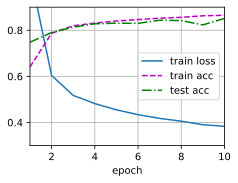

In [17]:
#训练
num_epochs,lr=10,0.1
updater=torch.optim.SGD(params,lr=lr)
d2l.train_ch3(net,train_iter,test_iter,loss,num_epochs,updater)

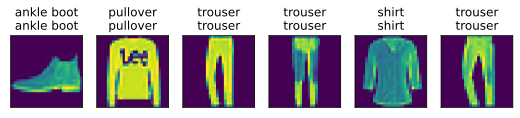

In [18]:
d2l.predict_ch3(net, test_iter)

多层感知机的简洁实现

In [19]:
import torch
from torch import nn
from d2l import torch as d2l

In [20]:
#模型
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

In [21]:
batch_size,lr,num_epochs=256,0.1,20
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

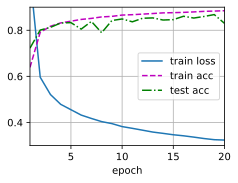

In [22]:
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net,train_iter,test_iter,loss,num_epochs,trainer)

模型选择 过拟合 欠拟合

In [23]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [24]:
max_degree=20
n_train,n_test=100,100
true_w=np.zeros(max_degree)
true_w[0:4]=np.array([5,1.2,-3.4,5.6])
features=np.random.normal(size=(n_train+n_test,1))
np.random.shuffle(features)
poly_features=np.power(features,np.arange(max_degree).reshape(1,-1))
for i in range(max_degree):
    poly_features[:,i] /= math.gamma(i+1)
labels=np.dot(poly_features,true_w)
labels += np.random.normal(scale=0.1,size=labels.shape)

In [25]:
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

In [26]:
features[:2], poly_features[:2, :], labels[:2]

(tensor([[ 0.3699],
         [-0.2547]]),
 tensor([[ 1.0000e+00,  3.6989e-01,  6.8409e-02,  8.4346e-03,  7.7997e-04,
           5.7700e-05,  3.5571e-06,  1.8796e-07,  8.6907e-09,  3.5718e-10,
           1.3212e-11,  4.4426e-13,  1.3694e-14,  3.8963e-16,  1.0294e-17,
           2.5385e-19,  5.8686e-21,  1.2769e-22,  2.6239e-24,  5.1082e-26],
         [ 1.0000e+00, -2.5467e-01,  3.2429e-02, -2.7529e-03,  1.7528e-04,
          -8.9276e-06,  3.7893e-07, -1.3786e-08,  4.3888e-10, -1.2419e-11,
           3.1628e-13, -7.3224e-15,  1.5540e-16, -3.0444e-18,  5.5380e-20,
          -9.4025e-22,  1.4966e-23, -2.2420e-25,  3.1721e-27, -4.2519e-29]]),
 tensor([5.1512, 4.4923]))

In [27]:
##训练模型
def evaluate_loss(net, data_iter, loss):
    metric = d2l.Accumulator(2)
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), y.numel())
    return metric[0] / metric[1]

In [28]:
#定义训练函数
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

weight: [[ 4.9868116  1.1874979 -3.3955402  5.621481 ]]


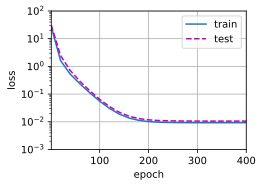

In [29]:
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[3.8248577 4.041433 ]]


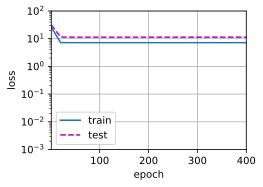

In [30]:
#欠拟合
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 4.9892259e+00  1.2743764e+00 -3.3779051e+00  5.1173205e+00
  -1.9964351e-01  1.3167660e+00  3.1102803e-01  3.6121136e-01
  -4.6542522e-02  9.3721151e-02 -1.8280098e-01  1.1708378e-01
  -5.2373540e-02 -1.6093644e-01  1.8127258e-01 -2.1354625e-01
   3.4367546e-02  1.5034551e-03  2.1727020e-01 -1.6795394e-01]]


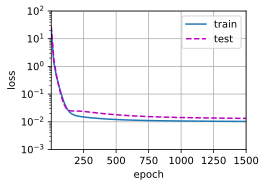

In [31]:
#过拟合
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

权重衰减

In [32]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [33]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [35]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [37]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

In [38]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

w的L2范数是： 12.821568489074707


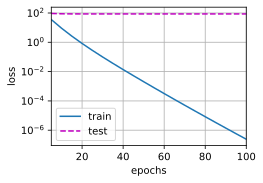

In [39]:
train(lambd=0)

w的L2范数是： 0.3940992057323456


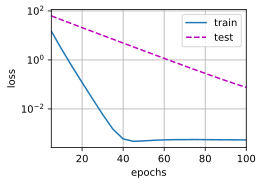

In [40]:
train(lambd=3)

简洁实现

In [42]:
def concise(wd):
    net=nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss=nn.MSELoss(reduction='none')
    num_epochs,lr=100,0.003
    trainer=torch.optim.SGD([
        {'params':net[0].weight,'weight_decay':wd},
        {'params':net[0].bias}], lr=lr)
    animator=d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l=loss(net(X),y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', net[0].weight.norm().item())

w的L2范数是： 14.682706832885742


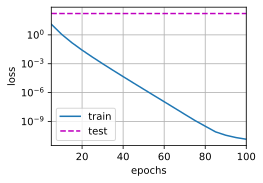

In [46]:
concise(0)

w的L2范数是： 0.4594753086566925


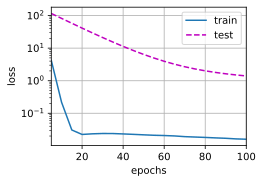

In [47]:
concise(3)

暂退法dropout

In [53]:
import torch
from torch import nn
from d2l import torch as d2l
def dropout_layer(X, dropout):
    assert 0<=dropout<=1
    if dropout==1:
        return torch.zeros_like(X)
    if dropout==0:
        return X
    mask=(torch.rand(X.shape)>dropout).float()
    return mask*X/ (1.0-dropout)

In [54]:
X= torch.arange(16, dtype = torch.float32).reshape((2, 8))
print(X)
print(drop_layer(X, 0.))
print(drop_layer(X, 0.5))
print(drop_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  2.,  4.,  0.,  0., 10., 12., 14.],
        [ 0.,  0.,  0.,  0., 24., 26.,  0., 30.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


In [55]:
#定义模型参数
num_inputs,num_outputs,num_hiddens1,num_hiddens2=784,10,256,256

In [59]:
#定义模型
dropout1,dropout2=0.2,0.5
class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training=True):
        super(Net, self).__init__()
        self.num_inputs=num_inputs
        self.training=is_training
        self.lin1=nn.Linear(num_inputs,num_hiddens1)
        self.lin2=nn.Linear(num_hiddens1,num_hiddens2)
        self.lin3=nn.Linear(num_hiddens2,num_outputs)
        self.relu=nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        if self.training == True:
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out
net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

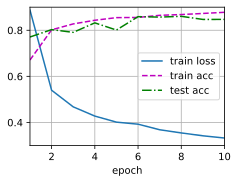

In [61]:
#训练与测试
num_epochs,lr,batch_size=10,0.5,256
loss=nn.CrossEntropyLoss(reduction='none')
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)
trainer=torch.optim.SGD(net.parameters(),lr=lr)
d2l.train_ch3(net,train_iter,test_iter,loss,num_epochs,trainer)

In [62]:
#简洁实现
net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),    
        nn.Dropout(dropout1),
        nn.Linear(256, 256),
        nn.ReLU(),
        nn.Dropout(dropout2),
        nn.Linear(256, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weights);

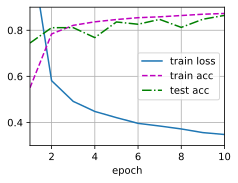

In [63]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

数值稳定性和模型初始化

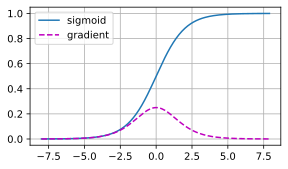

In [1]:
#梯度消失
%matplotlib inline
import torch
from d2l import torch as d2l
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))
d2l.plot(x.detach().numpy(), [y.detach().numpy(), x.grad.numpy()],
         legend=['sigmoid', 'gradient'], figsize=(4.5, 2.5))

In [2]:
#梯度爆炸
M = torch.normal(0, 1, size=(4,4))
print('一个矩阵 \n',M)
for i in range(100):
    M = torch.mm(M,torch.normal(0, 1, size=(4, 4)))
print('乘以100个矩阵后\n', M)

一个矩阵 
 tensor([[-1.5269, -0.6009,  1.1114,  1.2847],
        [ 0.8623, -0.6398,  1.3400, -1.5216],
        [ 0.2619, -0.0395,  1.7632,  0.9662],
        [ 1.2392, -0.9942, -0.3778, -0.5212]])
乘以100个矩阵后
 tensor([[-8.5375e+24, -5.1592e+24,  1.3445e+24,  4.4706e+24],
        [ 8.0098e+24,  4.8402e+24, -1.2614e+24, -4.1943e+24],
        [ 1.8511e+24,  1.1186e+24, -2.9151e+23, -9.6931e+23],
        [ 9.8436e+24,  5.9484e+24, -1.5502e+24, -5.1545e+24]])


环境与分布偏移